# 패키지 및 데이터

In [1]:
# ── 표준 라이브러리
from itertools import product

# ── 서드파티 라이브러리
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from pandas import DataFrame, Series

# ── scikit-learn: 파이프라인 & 전처리
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── scikit-learn: 모델 선택 & 검증
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

# ── scikit-learn: 평가 지표
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# ── XGBoost 회귀 모델
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── 사용자 정의 모듈
from hossam import *


In [2]:
origin = load_data("restaurant_sales_preprocessed")
origin.head()

어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)


,date,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
0,2024-01-01,16.169,122,14490,9.200,0.480,1.946,5.200,0,0
1,2024-01-02,16.005,106,11880,9.149,0.480,2.079,11.100,0,0
2,2024-01-03,16.354,120,18010,8.666,0.430,2.595,12.900,1,0
3,2024-01-04,16.082,115,11160,8.748,0.410,2.028,12.900,0,0
4,2024-01-05,16.113,124,15480,8.594,0.510,2.197,11.000,0,0


In [3]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("int")
origin["weekend"] = origin["weekend"].astype("int")
origin.info()



어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sales           353 non-null    float64
 1   visitors        353 non-null    int64  
 2   avg_price       353 non-null    int64  
 3   marketing_cost  353 non-null    float64
 4   delivery_ratio  353 non-null    float64
 5   rain_mm         353 non-null    float64
 6   temperature     353 non-null    float64
 7   holiday         353 non-null    int32  
 8   weekend         353 non-null    int32  
dtypes: float64(5), int32(2), int64(2)
memory usage: 24.8 KB


### 훈련,학습 데이터 분리

In [4]:
df = origin

yname = "sales"

#X에는 sales가 없음
X = df.drop(columns=[yname])
y = df[yname]

#testsize 를 75:25비율로 할당
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=52)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((264, 8), (89, 8), (264,), (89,))

### LightGBM 모델 적합

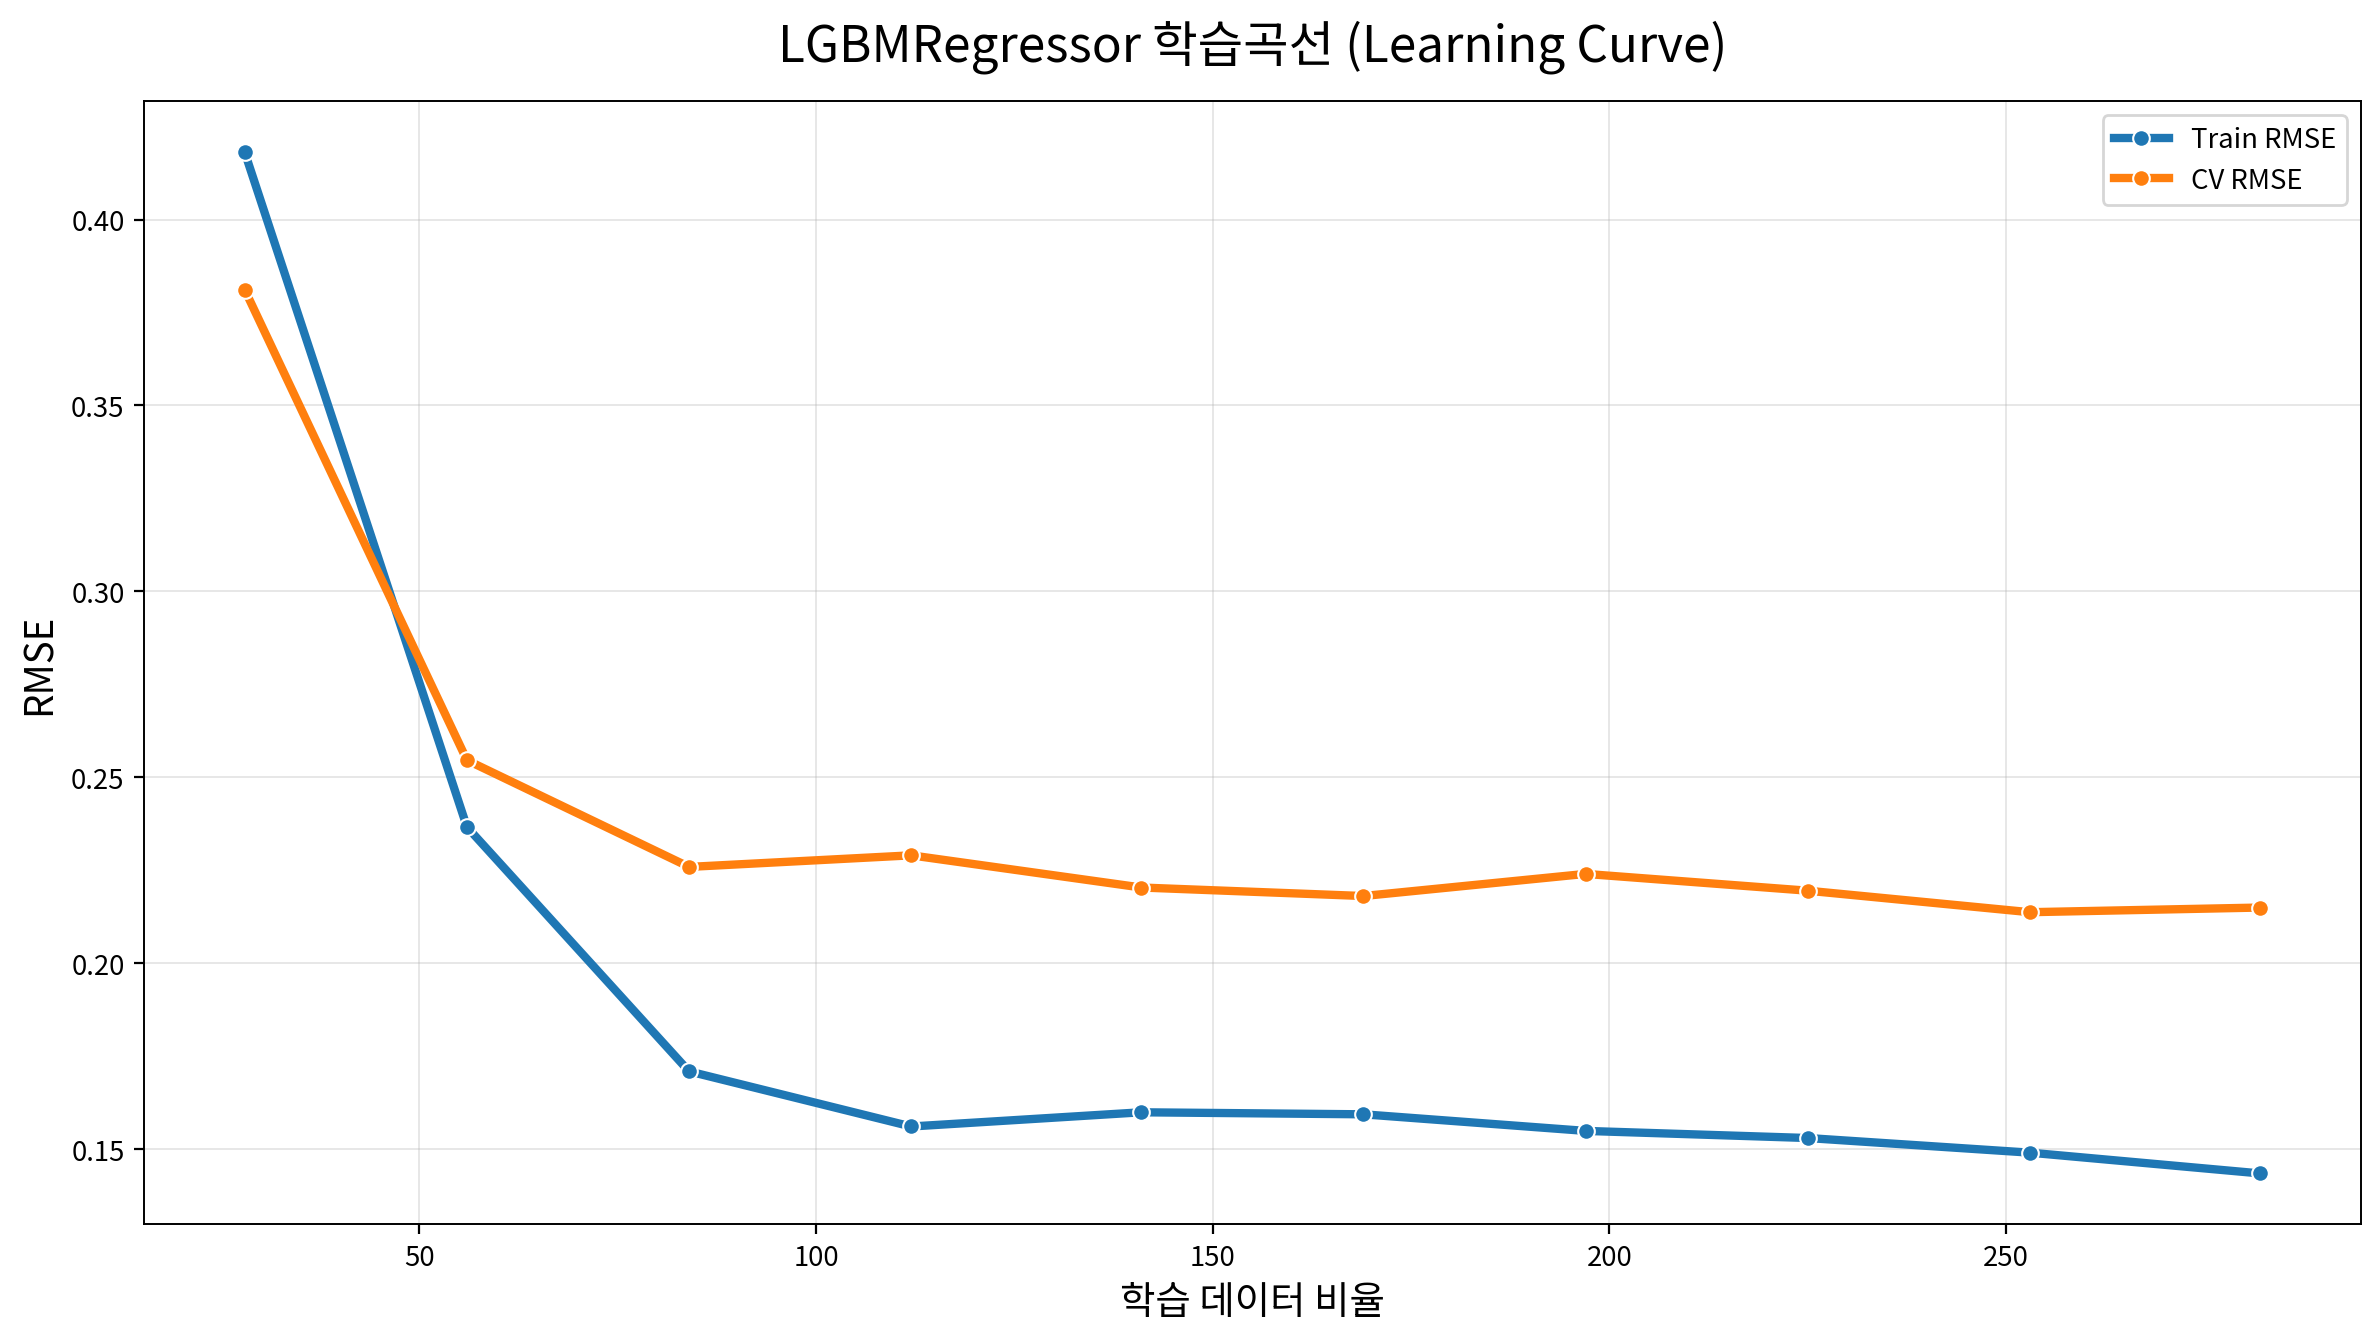

CPU times: total: 1.44 s
Wall time: 12.3 s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LGBMRegressor,0.861,0.113,0.020,0.142,0.007,-0.008,0.144,0.215,0.014,0.668,0.065,⚠️ 과대적합


In [9]:
%%time

lgbm = LGBMRegressor(
    objective = "regression",
    random_state = 52,
    n_jobs = -1,
    verbose = -1
)

param_grid = {
    "n_estimators":[200],
    "learning_rate" : [0.05,0.1],
    "num_leaves":[31, 63],
    "max_depth": [-1,5],
    "subsample":[0.8],
    "reg_alpha":[0,0.1,1],
    "reg_lambda":[0,1,5]
}

gs = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gs.fit(X_train, y_train)

best_model=gs.best_estimator_

best_model = gs.best_estimator_

hs_get_score_cv(best_model, X_train, y_train, X, y)

### 변수 중요도

In [12]:
booster = best_model.booster_
imp = booster.feature_importance(importance_type="gain")
imp

array([  7.7231264 ,  19.42568546,  23.14632095,   2.12844803,
        10.15928801,   2.99634064,  69.74150659, 154.66286766])

In [14]:
# ── 변수 중요도 DataFrame 생성
imp_df = DataFrame(
    {"importance": imp},
    index=best_model.feature_name_,
)

# ── 중요도 비율 계산
imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()

# ── 중요도 기준 내림차순 정렬
imp_df = imp_df.sort_values("importance", ascending=False)

# ── 누적 중요도 계산
imp_df["cumsum"] = imp_df["ratio"].cumsum()

imp_df


,importance,ratio,cumsum
weekend,154.663,0.533,0.533
holiday,69.742,0.241,0.774
marketing_cost,23.146,0.080,0.854
avg_price,19.426,0.067,0.921
rain_mm,10.159,0.035,0.956
visitors,7.723,0.027,0.982
temperature,2.996,0.010,0.993
delivery_ratio,2.128,0.007,1.000


### 변수 중요도 시각화

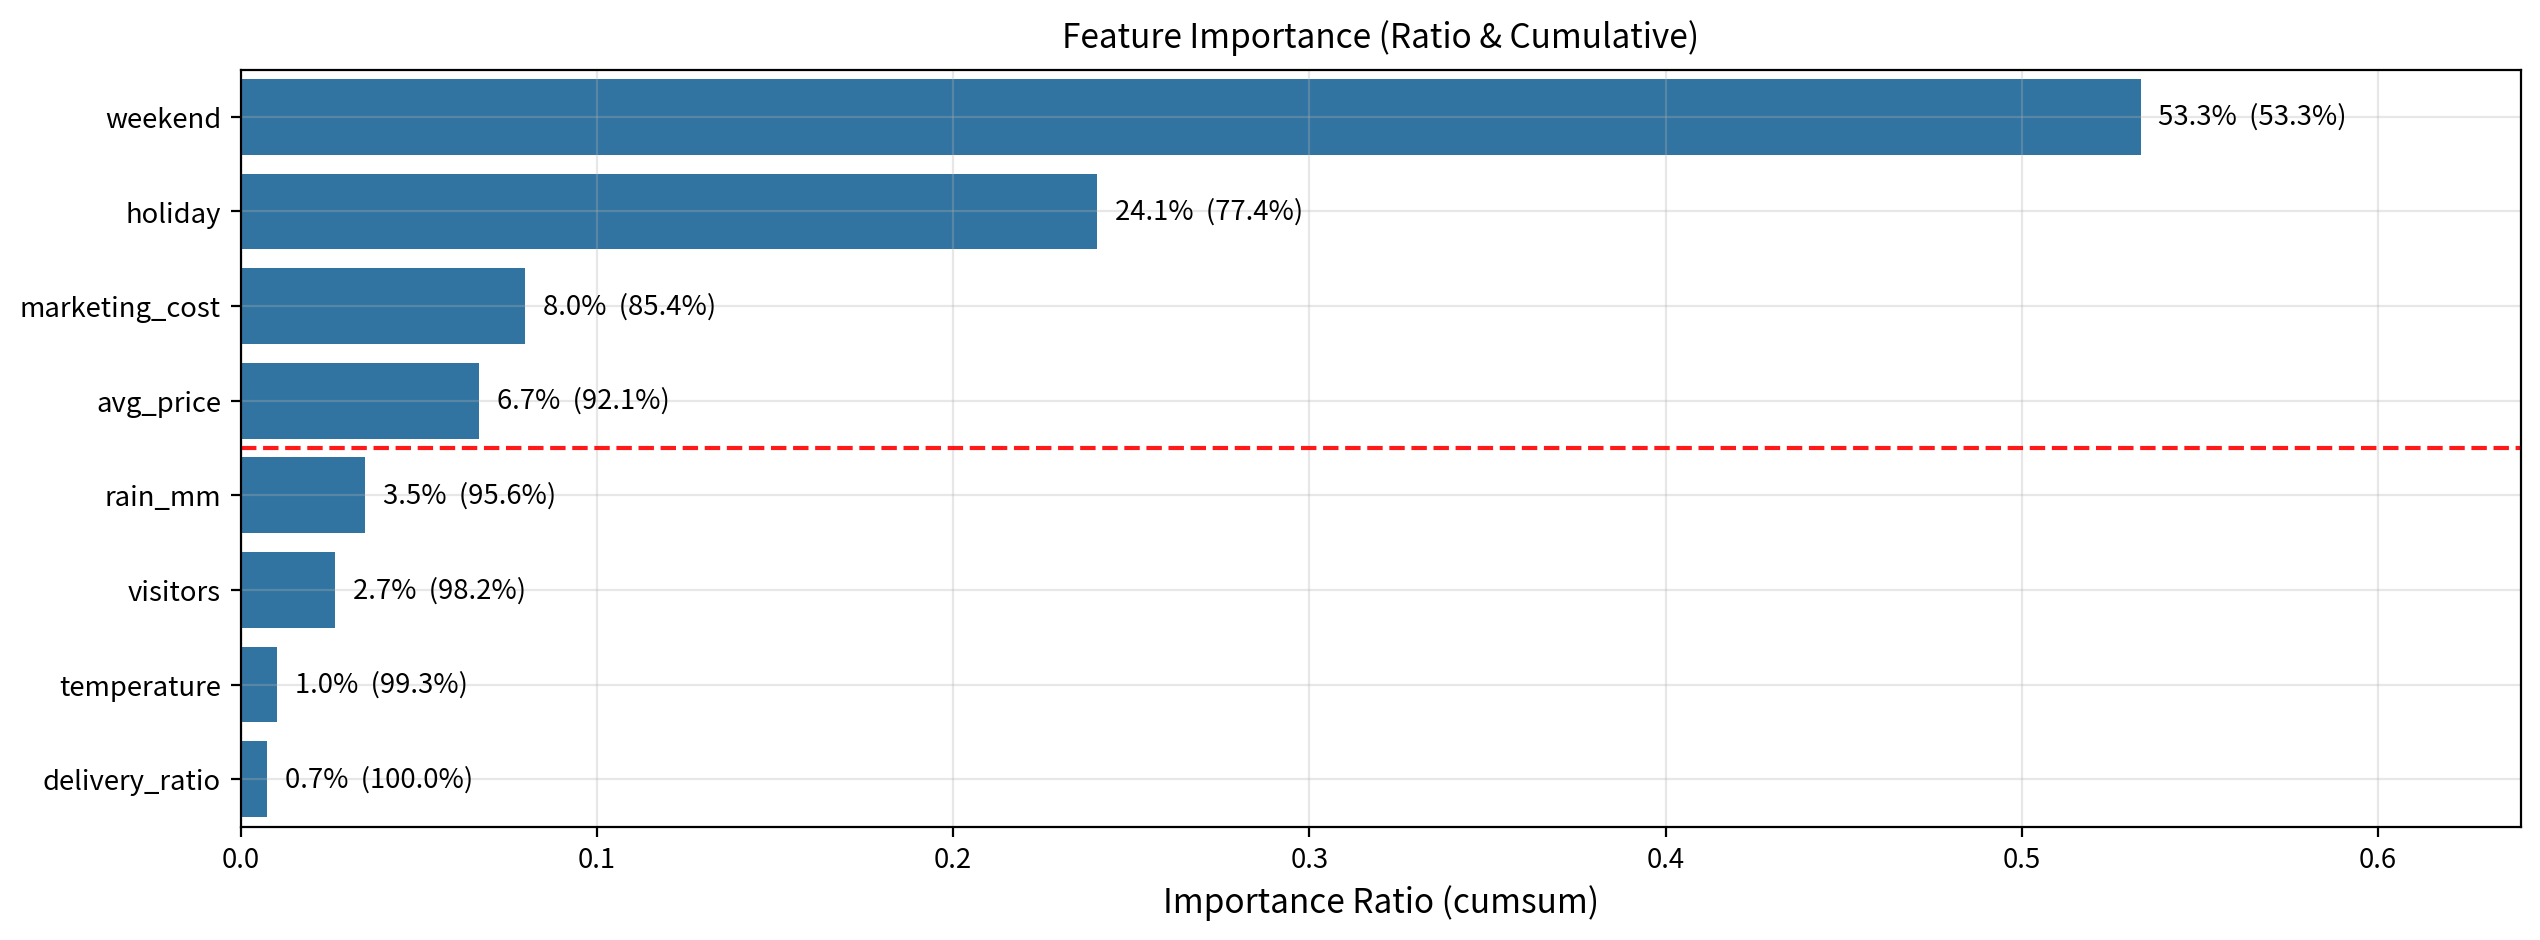

In [15]:
# ── Figure 크기 설정 (변수 개수에 따라 자동 조절)
height = len(imp_df) * 60
figsize = (1280 / 100, height / 100)

fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# ── 중요도 비율 바플롯
sb.barplot(
    data=imp_df,
    x="ratio",
    y=imp_df.index,
    orient="h",
    ax=ax,
)

# ── 각 변수에 비율 + 누적 비율 텍스트 표시
for i, v in enumerate(imp_df["ratio"]):
    ax.text(
        v + 0.005,          # 막대 끝에서 약간 오른쪽
        i,                  # y 위치
        f"{v:.1%}  ({imp_df.iloc[i]['cumsum']*100:.1f}%)",
        va="center",
    )

# ── 축 / 제목 설정
ax.set_title("Feature Importance (Ratio & Cumulative)", fontsize=12, pad=8)
ax.set_xlabel("Importance Ratio (cumsum)", fontsize=12)
ax.set_ylabel(None)
ax.grid(True, alpha=0.3)

# ── x축 범위
ax.set_xlim(0, imp_df["ratio"].max() * 1.2)

# ── 누적 90% 컷라인 계산
threshold = 0.9
cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)
cut_rank = cut_idx + 0.5  # rank 기준 보정

# ── 90% 도달 지점 시각화
ax.axhline(
    y=cut_rank,
    linestyle="--",
    color="red",
    alpha=0.9,
)

# ── 출력
plt.tight_layout()
plt.show()
plt.close()


### 변수 중요도 확인 함수 개선

In [16]:
def hs_feature_importance(model, X_train, y_train):
    """
    모델 종류에 따라 feature importance를 계산하고
    비율(ratio) 및 누적 중요도(cumsum)를 반환
    """

    # ─────────────────────────────────────
    # 1. 모델별 중요도 계산
    # ─────────────────────────────────────
    if isinstance(model, XGBRegressor):
        booster = model.get_booster()
        imp_dict = booster.get_score(importance_type="gain")

        imp_df = (
            Series(imp_dict, name="importance")
            .to_frame()
        )

    elif isinstance(model, LGBMRegressor):
        imp = model.booster_.feature_importance(importance_type="gain")

        imp_df = DataFrame(
            {"importance": imp},
            index=model.feature_name_,
        )

    else:
        # Permutation Importance (범용)
        perm = permutation_importance(
            estimator=model,
            X=X_train,
            y=y_train,
            scoring="r2",
            n_repeats=30,
            random_state=42,
            n_jobs=-1,
        )

        imp_df = DataFrame(
            {"importance": perm.importances_mean},
            index=X_train.columns,
        )

    # ─────────────────────────────────────
    # 2. 중요도 비율 + 누적 중요도 계산
    # ─────────────────────────────────────
    imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()

    imp_df = (
        imp_df
        .sort_values("ratio", ascending=False)
    )

    imp_df["cumsum"] = imp_df["ratio"].cumsum()

    return imp_df


In [17]:
imp_df = hs_feature_importance(best_model, X_train, y_train)
imp_df


,importance,ratio,cumsum
weekend,154.663,0.533,0.533
holiday,69.742,0.241,0.774
marketing_cost,23.146,0.080,0.854
avg_price,19.426,0.067,0.921
rain_mm,10.159,0.035,0.956
visitors,7.723,0.027,0.982
temperature,2.996,0.010,0.993
delivery_ratio,2.128,0.007,1.000
